# Process variables analysis

This notebook presents a study of operational limits in the processes variables to prevent failures.

In [1]:
# Imports
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from local_settings import postgres_url as url_dict
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
%matplotlib inline

In [2]:
# Load 'milling_pdm_celsius' dataset to a pandas dataframe
url = f"postgresql+psycopg2://{url_dict['pguser']}:{url_dict['pgpasswd']}@{url_dict['pghost']}/{url_dict['pgdb']}"
engine = create_engine(url)
df = pd.read_sql(f"SELECT * FROM milling_pdm_celsius",con=engine, index_col="register_id")
df

,product_id,product_type,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,heat_dissipation_failure,power_failure,overstrain_failure,random_failure
register_id,,,,,,,,,,,,,
1,M14860,M,24.950006,35.450006,1551.0,42.8,0,False,False,False,False,False,False
2,L47181,L,25.050012,35.550012,1408.0,46.3,3,False,False,False,False,False,False
3,L47182,L,24.950006,35.350000,1498.0,49.4,5,False,False,False,False,False,False
4,L47183,L,25.050012,35.450006,1433.0,39.5,7,False,False,False,False,False,False
5,L47184,L,25.050012,35.550012,1408.0,40.0,9,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,M24855,M,25.649988,35.249994,1604.0,29.5,14,False,False,False,False,False,False
9997,H39410,H,25.749994,35.249994,1632.0,31.8,17,False,False,False,False,False,False
9998,M24857,M,25.850000,35.450006,1645.0,33.4,22,False,False,False,False,False,False


In [3]:
# Load 'failure_data_unpivoted' dataset to a pandas dataframe
df_failure_mode = pd.read_sql(f"SELECT * FROM failure_data_unpivoted",con=engine, index_col="register_id")
df_failure_mode

,product_type,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,machine_failure,status
register_id,,,,,,,
1,M,24.950006,35.450006,1551.0,42.8,False,NORMAL
2,L,25.050012,35.550012,1408.0,46.3,False,NORMAL
3,L,24.950006,35.350000,1498.0,49.4,False,NORMAL
4,L,25.050012,35.450006,1433.0,39.5,False,NORMAL
5,L,25.050012,35.550012,1408.0,40.0,False,NORMAL
...,...,...,...,...,...,...,...
9996,M,25.649988,35.249994,1604.0,29.5,False,NORMAL
9997,H,25.749994,35.249994,1632.0,31.8,False,NORMAL
9998,M,25.850000,35.450006,1645.0,33.4,False,NORMAL


In [4]:
# Add new features

## Mechanical Power in kW
df["rotational_speed_rps"] = 2*np.pi*df["rotational_speed_rpm"] / 60 # Convert rotational speed to rad/s
df["mech_power_kwatts"] = (df["rotational_speed_rps"] * df["torque_nm"])/1000 # Create a column for mechanical power in kW
df_failure_mode["mech_power_kwatts"] = df["mech_power_kwatts"]

## Temperature difference in °C
df["delta_temperature_celsius"] = df["process_temperature_celsius"] - df["air_temperature_celsius"]
df_failure_mode["delta_temperature_celsius"] = df["delta_temperature_celsius"]

## Time-series plot of process variables

Investigate whether process variables exhibit operational limits or temporal patterns associated with failure events.

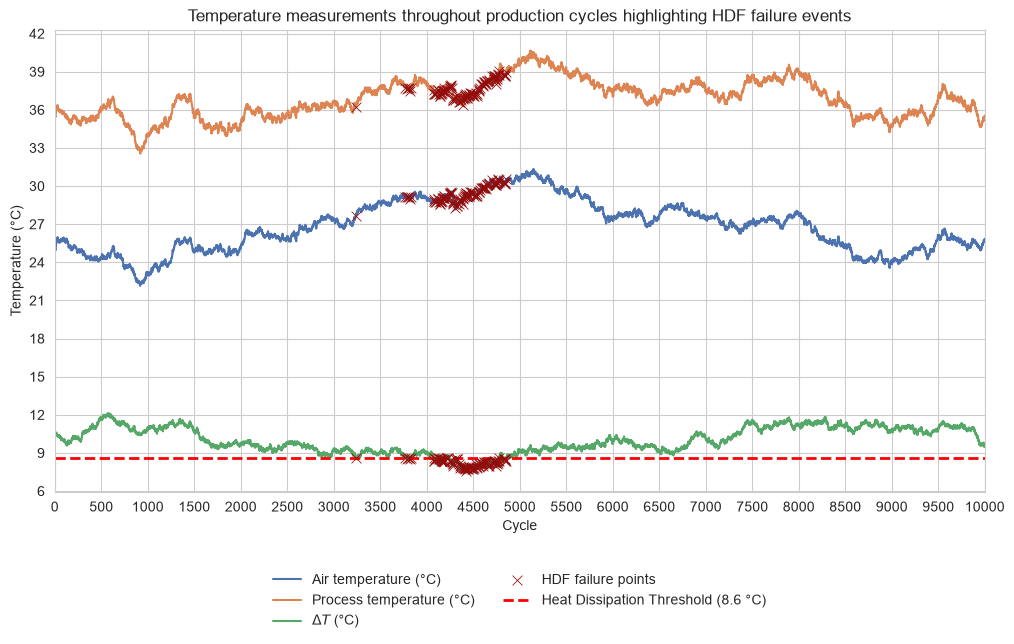

In [5]:
# Time-series plot of air_temperature_celsius, process_temperature_celsius and temperature difference

## Create a temperature dataframe with only temperature and failure columns
df_temp = df_failure_mode[["air_temperature_celsius", "process_temperature_celsius", "delta_temperature_celsius"]]
rename_dict = {"air_temperature_celsius": "Air temperature (°C)",
               "process_temperature_celsius": "Process temperature (°C)",
               "delta_temperature_celsius": r"$\Delta T$ (°C)"}

## Create failure mode dataframe with only temperature columns and filtered for HDF failures status
df_hdf = df_failure_mode[df_failure_mode["status"]=="HDF"]
df_hdf = pd.concat([df_hdf["air_temperature_celsius"], df_hdf["process_temperature_celsius"], df_hdf["delta_temperature_celsius"]], join='outer')

## Calculate threshold on temperature difference for HDF
temp_thresh = max(df_failure_mode[df_failure_mode["status"]=="HDF"]["delta_temperature_celsius"])

## Plot time-series
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.lineplot(data=df_temp.rename(columns=rename_dict),
             dashes=False,
             palette="deep")

## Plot failures
sns.scatterplot(data=df_hdf,
                marker="x",
                s=50,
                color="#920C0C",
                zorder=5,
                label="HDF failure points");

## Plot variable limits
plt.axhline(
    y=temp_thresh, 
    color='red', 
    linestyle='--',
    linewidth=2, 
    label=f'Heat Dissipation Threshold ({temp_thresh:.1f} °C)'
)
print("")

## Plot settings
plt.xlim(left=0, right=10000)
plt.xticks(np.arange(0,10001,500))
plt.yticks(np.arange(6,43,3))
plt.title("Temperature measurements throughout production cycles highlighting HDF failure events")
plt.xlabel("Cycle")
plt.ylabel("Temperature (°C)")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2, 
    frameon=False
)
plt.show()

In [6]:
# If the threshold is used as an alarm, how many false positives it would give?
total_points = df_failure_mode[(df_failure_mode["delta_temperature_celsius"]<=temp_thresh)].shape[0]
false_positives = df_failure_mode[(df_failure_mode["delta_temperature_celsius"]<=temp_thresh) & (df_failure_mode["status"]!="HDF")].shape[0]
print(f"The alarm should ring at {total_points} points, giving a total of {false_positives} false positives ({false_positives/total_points*100:.0f}%)")

The alarm should ring at 814 points, giving a total of 699 false positives (86%)


- Both air and process temperatures exhibit a drifting behavior rather than a steady state. This raises two physical hypotheses: either the thermal sensors are degrading over time, or the machine is transitioning between distinct operating regimes. Since manufacturing plants often run products of the same quality in continuous batches (campaigns), our next step is to investigate the production sequence to see if these temperature shifts align with product changeovers.

- Plotting the heat dissipation failure points along with the temperatures we can identify a lower limit in temperature difference at 8.6°C that triggers this failure mode. However, using this trigger as an alarm threshold would generate a total of 699 false positives which corresponds to 86% of the alerts, indicating that another variable should be involved in the heat dissipation failure trigger.

- Furthermore, the discovery of a crisp, well-defined mathematical threshold for HDF failures at strictly $8.6^\circ\text{C}$ strongly discards the hypothesis of sensor drift, confirming that the sensor readings are able to capture the failure event threshold, obtained by getting the highest temperature difference in the dataframe filtered by the HDF failure.

- All the other failure modes presented points equaly distributed accros temperatures.

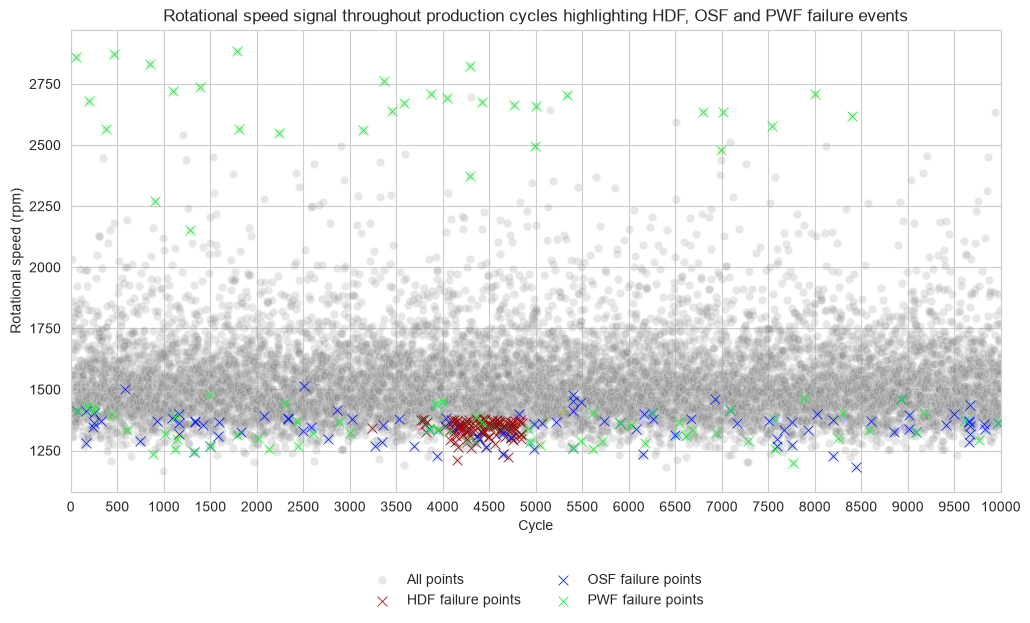

In [7]:
# Time-series plot of rotational_speed_rpm

## Create a dataframe with only rotational speed and failure columns
df_speed = df_failure_mode["rotational_speed_rpm"]
rename_dict = {"rotational_speed_rpm": "Rotational speed (rpm)"}

## Create failure mode dataframe with HDF points
df_hdf = df_failure_mode[df_failure_mode["status"]=="HDF"]
df_hdf = df_hdf["rotational_speed_rpm"]

## Create failure mode dataframe with OSF points
df_osf = df_failure_mode[df_failure_mode["status"]=="OSF"]
df_osf = df_osf["rotational_speed_rpm"]

## Create failure mode dataframe with PWF points
df_pwf = df_failure_mode[df_failure_mode["status"]=="PWF"]
df_pwf = df_pwf["rotational_speed_rpm"]

## Plot time-series
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
# sns.lineplot(data=df_speed.rename(rename_dict))
sns.scatterplot(data=df_speed.rename(rename_dict),
                alpha=0.2,
                color="#858585",
                label="All points")

# Plot failures
sns.scatterplot(data=df_hdf,
                marker="x",
                s=50,
                color="#920C0C",
                zorder=5,
                label="HDF failure points");

sns.scatterplot(data=df_osf,
                marker="x",
                s=50,
                color="#001AFF",
                zorder=5,
                label="OSF failure points");

sns.scatterplot(data=df_pwf,
                marker="x",
                s=50,
                color="#00FF22",
                zorder=5,
                label="PWF failure points");

## Plot settings
plt.xlim(left=0, right=10000)
plt.xticks(np.arange(0,10001,500))
plt.title("Rotational speed signal throughout production cycles highlighting HDF, OSF and PWF failure events")
plt.xlabel("Cycle")
plt.ylabel("Rotational speed (rpm)")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2, 
    frameon=False
)
plt.show()

- The rotational speed time series exhibits high-frequency fluctuations and variance during operational cycles, which necessitated the use of a scatter plot to better visualize data density across operating ranges. This behavior is typical for CNC machines, as the motor control system constantly balances rotational speed and torque against variable friction levels induced by materials of differing hardness.

- Furthermore, time-series analysis reveals that all HDF failure points occur below 1380 RPM, and all OSF failure points occur below 1515 RPM. However, since a large volume of non-failure data points also exists outside these thresholds, these speed limits alone are insufficient for predictive failure modeling. Given these results, a multivariate approach (combining speed with torque or temperature) is required to achieve meaningful failure prediction.

- PWF failure points exhibits two limits in the time series: above 2153 rpm and below 1479 N.m. Further investigation to verify wether these limits are related to different failure modes is required.

- TWF and RDF are equaly distributed between torque values and were not presented in the time-series graph.

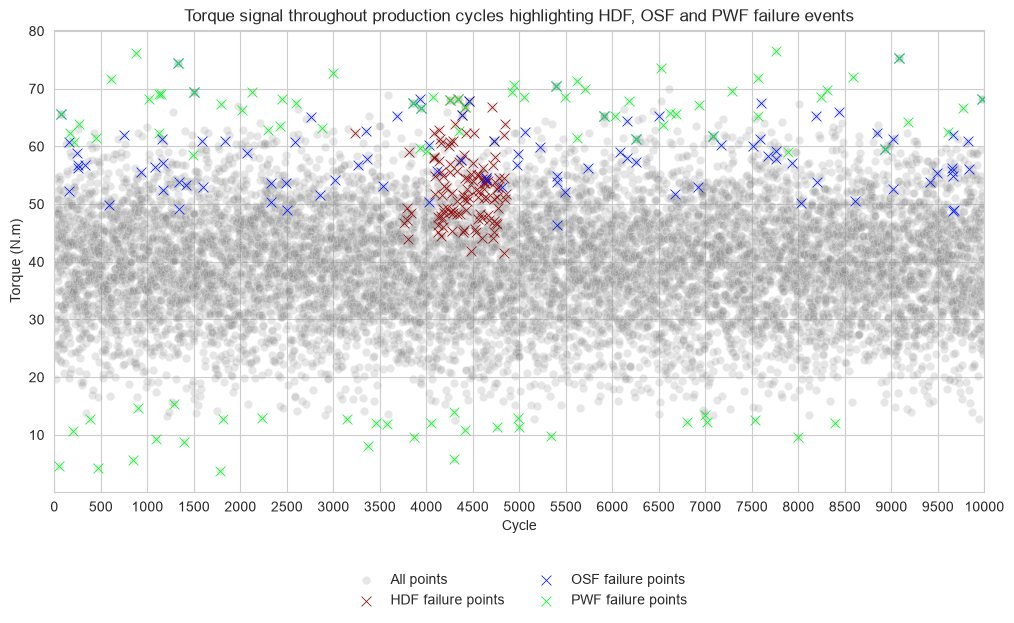

In [8]:
# Time-series plot of torque_nm

## Create a dataframe with only torque and failure columns
df_torque = df_failure_mode["torque_nm"]
rename_dict = {"torque_nm": "Torque (N.m)"}

## Create failure mode dataframe with HDF points
df_hdf = df_failure_mode[df_failure_mode["status"]=="HDF"]
df_hdf = df_hdf["torque_nm"]

## Create failure mode dataframe with OSF points
df_osf = df_failure_mode[df_failure_mode["status"]=="OSF"]
df_osf = df_osf["torque_nm"]

## Create failure mode dataframe with PWF points
df_pwf = df_failure_mode[df_failure_mode["status"]=="PWF"]
df_pwf = df_pwf["torque_nm"]

## Calculate threshold on temperature difference for HDF
# temp_thresh = max(df_failure_mode[df_failure_mode["status"]=="HDF"]["delta_temperature_celsius"])

## Plot time-series
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
# sns.lineplot(data=df_torque.rename(rename_dict))
sns.scatterplot(data=df_torque.rename(rename_dict),
                alpha=0.2,
                color="#858585",
                label="All points")

# Plot failures
sns.scatterplot(data=df_hdf,
                marker="x",
                s=50,
                color="#920C0C",
                zorder=5,
                label="HDF failure points");

sns.scatterplot(data=df_osf,
                marker="x",
                s=50,
                color="#001AFF",
                zorder=5,
                label="OSF failure points");

sns.scatterplot(data=df_pwf,
                marker="x",
                s=50,
                color="#00FF22",
                zorder=5,
                label="PWF failure points");

## Plot settings
plt.xlim(left=0, right=10000)
plt.xticks(np.arange(0,10001,500))
plt.title("Torque signal throughout production cycles highlighting HDF, OSF and PWF failure events")
plt.xlabel("Cycle")
plt.ylabel("Torque (N.m)")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2, 
    frameon=False
)
plt.show()

- The same behaviour of high-frequency fluctuations and variance is observed for the torque signal for the same reason used to explain the rotational speed behaviour.

- Furthermore, time-series analysis reveals that all HDF failure points occur above 41.6 N.m, and all OSF failure points occur above 46.3 N.m. However, as observed for the rotational speed, since a large volume of non-failure data points also exists above these thresholds, these torque limits alone are insufficient for predictive failure modeling.

- PWF failure points exhibits two limits in the time series: above 58.5 N.m and below 15.3 N.m. Further investigation to verify wether these limits are related to different failure modes is required.

- TWF and RDF are equaly distributed between torque values and were not presented in the time-series graph.

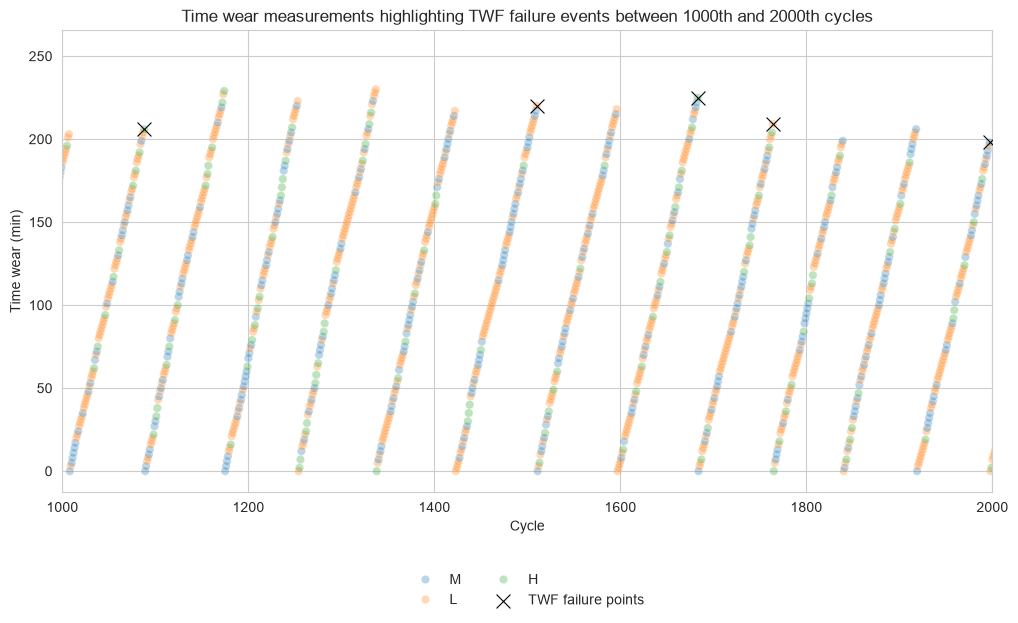

In [9]:
# Time-series plot of tool_wear_min

## Create a dataframe with only tool wear and failure columns
df_wear = df["tool_wear_min"]
rename_dict = {"tool_wear_min": "Tool wear (min)"}

## Create failure mode dataframe with TWF points
df_twf = df[df["tool_wear_failure"]]
df_twf = df_twf["tool_wear_min"]

## Plot time-series
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.scatterplot(x="register_id",
                y="tool_wear_min",
                data=df,
                hue="product_type",
                alpha=0.3)

## Plot failures
sns.scatterplot(data=df_twf,
                marker="x",
                s=100,
                color="#000000",
                zorder=5,
                label="TWF failure points")

## Plot settings
plt.xlim(left=1000, right=2000)
#plt.xticks(np.arange(0,10001,500))
plt.title("Time wear measurements highlighting TWF failure events between 1000th and 2000th cycles")
plt.xlabel("Cycle")
plt.ylabel("Time wear (min)")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2, 
    frameon=False
)
plt.show()

- The analysis of tool wear relative to operation cycles shows that the same tool is used across a sequence of machining operations with varying product qualities before replacement, resetting the wear counter. Furthermore, not all tool change events coincide with Tool Wear Failure (TWF), indicating the application of a preventive maintenance policy triggered by multivariant criteria rather than the wear counter alone. As tool wear values at the moment of preventive replacement are inconsistent, the wear counter is clearly not the sole determinant for component substitution.

- The scatter plot, categorized by product quality, provides visual evidence that products are machined in a random order rather than in distinct production campaigns. This lack of clustering suggests that the observed thermal and wear behavior does not correlate directly with the product mix.

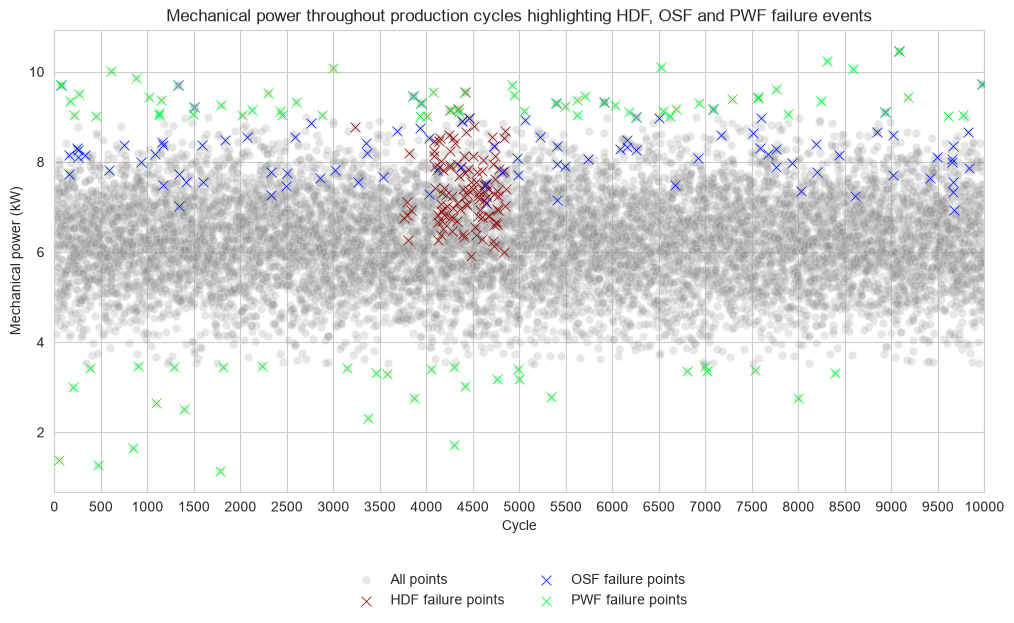

In [10]:
# Time-series plot of mechanical power (kW)

## Create a dataframe with only power and failure columns
df_power = df_failure_mode["mech_power_kwatts"]
rename_dict = {"mech_power_kwatts": "Mechanical power (kW)"}

## Create failure mode dataframe with HDF points
df_hdf = df_failure_mode[df_failure_mode["status"]=="HDF"]
df_hdf = df_hdf["mech_power_kwatts"]

## Create failure mode dataframe with OSF points
df_osf = df_failure_mode[df_failure_mode["status"]=="OSF"]
df_osf = df_osf["mech_power_kwatts"]

## Create failure mode dataframe with PWF points
df_pwf = df_failure_mode[df_failure_mode["status"]=="PWF"]
df_pwf = df_pwf["mech_power_kwatts"]

## Calculate threshold on temperature difference for HDF
# temp_thresh = max(df_failure_mode[df_failure_mode["status"]=="HDF"]["delta_temperature_celsius"])

## Plot time-series
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
# sns.lineplot(data=df_power.rename(rename_dict))
sns.scatterplot(data=df_power.rename(rename_dict),
                alpha=0.2,
                color="#858585",
                label="All points")

# Plot failures
sns.scatterplot(data=df_hdf,
                marker="x",
                s=50,
                color="#920C0C",
                zorder=5,
                label="HDF failure points");

sns.scatterplot(data=df_osf,
                marker="x",
                s=50,
                color="#001AFF",
                zorder=5,
                label="OSF failure points");

sns.scatterplot(data=df_pwf,
                marker="x",
                s=50,
                color="#00FF22",
                zorder=5,
                label="PWF failure points");

## Plot settings
plt.xlim(left=0, right=10000)
plt.xticks(np.arange(0,10001,500))
plt.title("Mechanical power throughout production cycles highlighting HDF, OSF and PWF failure events")
plt.xlabel("Cycle")
plt.ylabel("Mechanical power (kW)")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2, 
    frameon=False
)
plt.show()

In [37]:
df[(df["mech_power_kwatts"]>9) | (df["mech_power_kwatts"]<3.5)]["power_failure"].value_counts()

power_failure
True    95
Name: count, dtype: int64

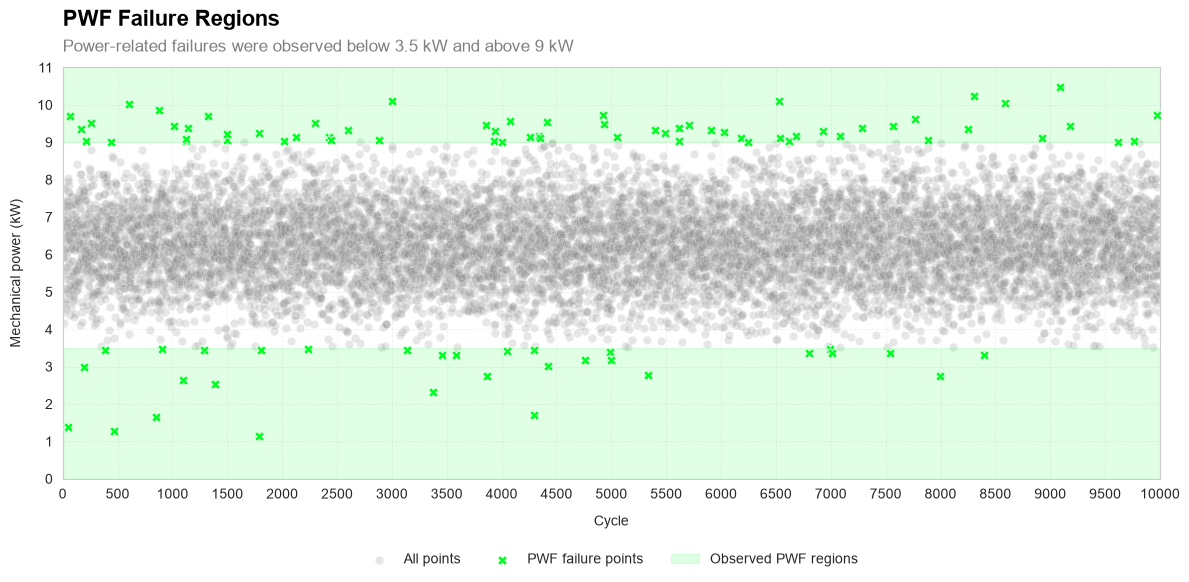

In [85]:
# Time-series plot of mechanical power (kW)

## Create a dataframe with only power and failure columns
df_power = df_failure_mode["mech_power_kwatts"]
rename_dict = {"mech_power_kwatts": "Mechanical power (kW)"}

## Create failure mode dataframe with HDF points
df_hdf = df_failure_mode[df_failure_mode["status"]=="HDF"]
df_hdf = df_hdf["mech_power_kwatts"]

## Create failure mode dataframe with OSF points
df_osf = df_failure_mode[df_failure_mode["status"]=="OSF"]
df_osf = df_osf["mech_power_kwatts"]

## Create failure mode dataframe with PWF points
df_pwf = df_failure_mode[df_failure_mode["status"]=="PWF"]
df_pwf = df_pwf["mech_power_kwatts"]

## Calculate threshold on temperature difference for HDF
# temp_thresh = max(df_failure_mode[df_failure_mode["status"]=="HDF"]["delta_temperature_celsius"])

## Plot time-series
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
# sns.lineplot(data=df_power.rename(rename_dict))
sns.scatterplot(data=df_power.rename(rename_dict),
                alpha=0.2,
                color="#858585",
                label="All points")

# Plot failures
sns.scatterplot(data=df_pwf,
                marker="X",
                s=50,
                color="#00FF22",
                zorder=5,
                label="PWF failure points");

ax = plt.gca()

# Thresholds
upper_power_thresh = 9
lower_power_thresh = 3.5

# Observed TWF range
ax.axhspan(
    ymin=upper_power_thresh,
    ymax=15,
    alpha=0.12,
    label="Observed PWF regions",
    color="#00FF22"
)

ax.axhspan(
    ymin=0,
    ymax=lower_power_thresh,
    alpha=0.12,
    color="#00FF22"
)

## Plot settings

# Title
ax.set_title(
    "HDF Operating Conditions",
    fontsize=16,
    fontweight="bold",
    color="black",
    loc="left",
    pad=25
)

## Title and Subtitle
# Title
ax.set_title(
    "PWF Failure Regions",
    fontsize=16,
    fontweight="bold",
    color="black",
    loc="left",
    pad=30
)

# Subtitle
ax.text(
    0, 1.03,
    "Power-related failures were observed below 3.5 kW and above 9 kW",
    transform=ax.transAxes,
    fontsize=12,
    color="gray",
    ha="left",
    va="bottom"
)

## Plot settings
ax.set_xlim(left=0, right=10000)
ax.set_ylim(bottom=0, top=11)
ax.set_xticks(np.arange(0,10001,500))
ax.set_yticks(np.arange(0,12,1))
ax.set_xlabel("Cycle", labelpad=10)
ax.set_ylabel("Mechanical power (kW)", labelpad=10)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3, 
    frameon=False
)

# Grid
# Grid
ax.grid(
    axis="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.3
)

plt.tight_layout()
plt.savefig("../doc/pwf_failure_regions.png")
plt.show()

- The same behaviour of high-frequency fluctuations and variance is observed for the mechanical power signal for the same reason used to explain the variables it is derived from, rotational speed and torque.

- Furthermore, time-series analysis reveals that all HDF failure points occur above 5.9 kW, and all OSF failure points occur above 6.9 kW. However, as observed for the rotational speed, since a large volume of non-failure data points also exists above these thresholds, these torque limits alone are insufficient for predictive failure modeling.

- Power failures occur at all points above 9 kW and bellow 3.5 kW.

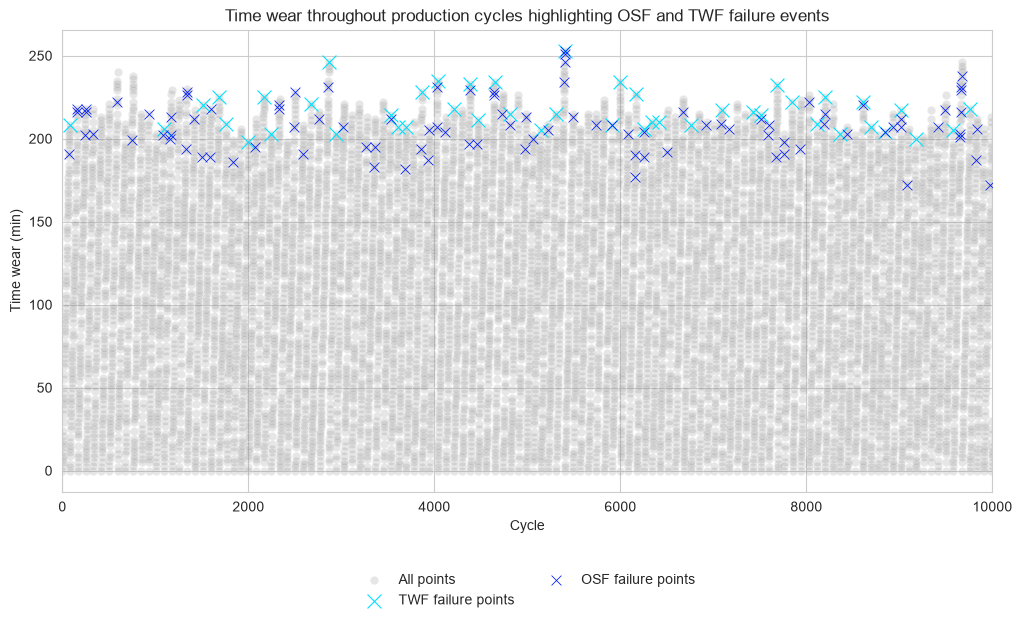

In [12]:
# Time-series plot of tool_wear_min

## Create a dataframe with only tool wear and failure columns
df_wear = df["tool_wear_min"]
rename_dict = {"tool_wear_min": "Tool wear (min)"}

## Create failure mode dataframe with TWF points
df_twf = df[df["tool_wear_failure"]]
df_twf = df_twf["tool_wear_min"]

## Create failure mode dataframe with OSF points
df_osf = df[df["overstrain_failure"]]
df_osf = df_osf["tool_wear_min"]

## Plot time-series
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.scatterplot(x="register_id",
                y="tool_wear_min",
                data=df,
                alpha=0.2,
                color="#858585",
                label="All points")

## Plot failures
sns.scatterplot(data=df_twf,
                marker="x",
                s=100,
                color="#00E1FF",
                zorder=5,
                label="TWF failure points")

sns.scatterplot(data=df_osf,
                marker="x",
                s=50,
                color="#001AFF",
                zorder=5,
                label="OSF failure points");

## Plot settings
plt.xlim(left=0, right=10000)
#plt.xticks(np.arange(0,10001,500))
plt.title("Time wear throughout production cycles highlighting OSF and TWF failure events")
plt.xlabel("Cycle")
plt.ylabel("Time wear (min)")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2, 
    frameon=False
)
plt.show()

- Tool Wear Failures (TWF) are predominantly observed between 198 and 253 wear minutes of operation. This cluster indicates that the useful life of the tool is effectively bounded within this range, serving as a critical indicator for planned replacement strategies.

- Overstrain Failures (OSF) consistently manifest after 172 minutes of wear, suggesting a correlation between cumulative material damage and the tool's structural integrity. This implies that the probability of overstrain increases significantly as the tool's fatigue resistance diminishes over time.

- In contrast, other failure modes exhibit a uniform distribution across the tool's wear spectrum, indicating that these events—such as thermal dissipation (HDF) or power-related failures (PWF)—are likely independent of the tool's cumulative usage time.

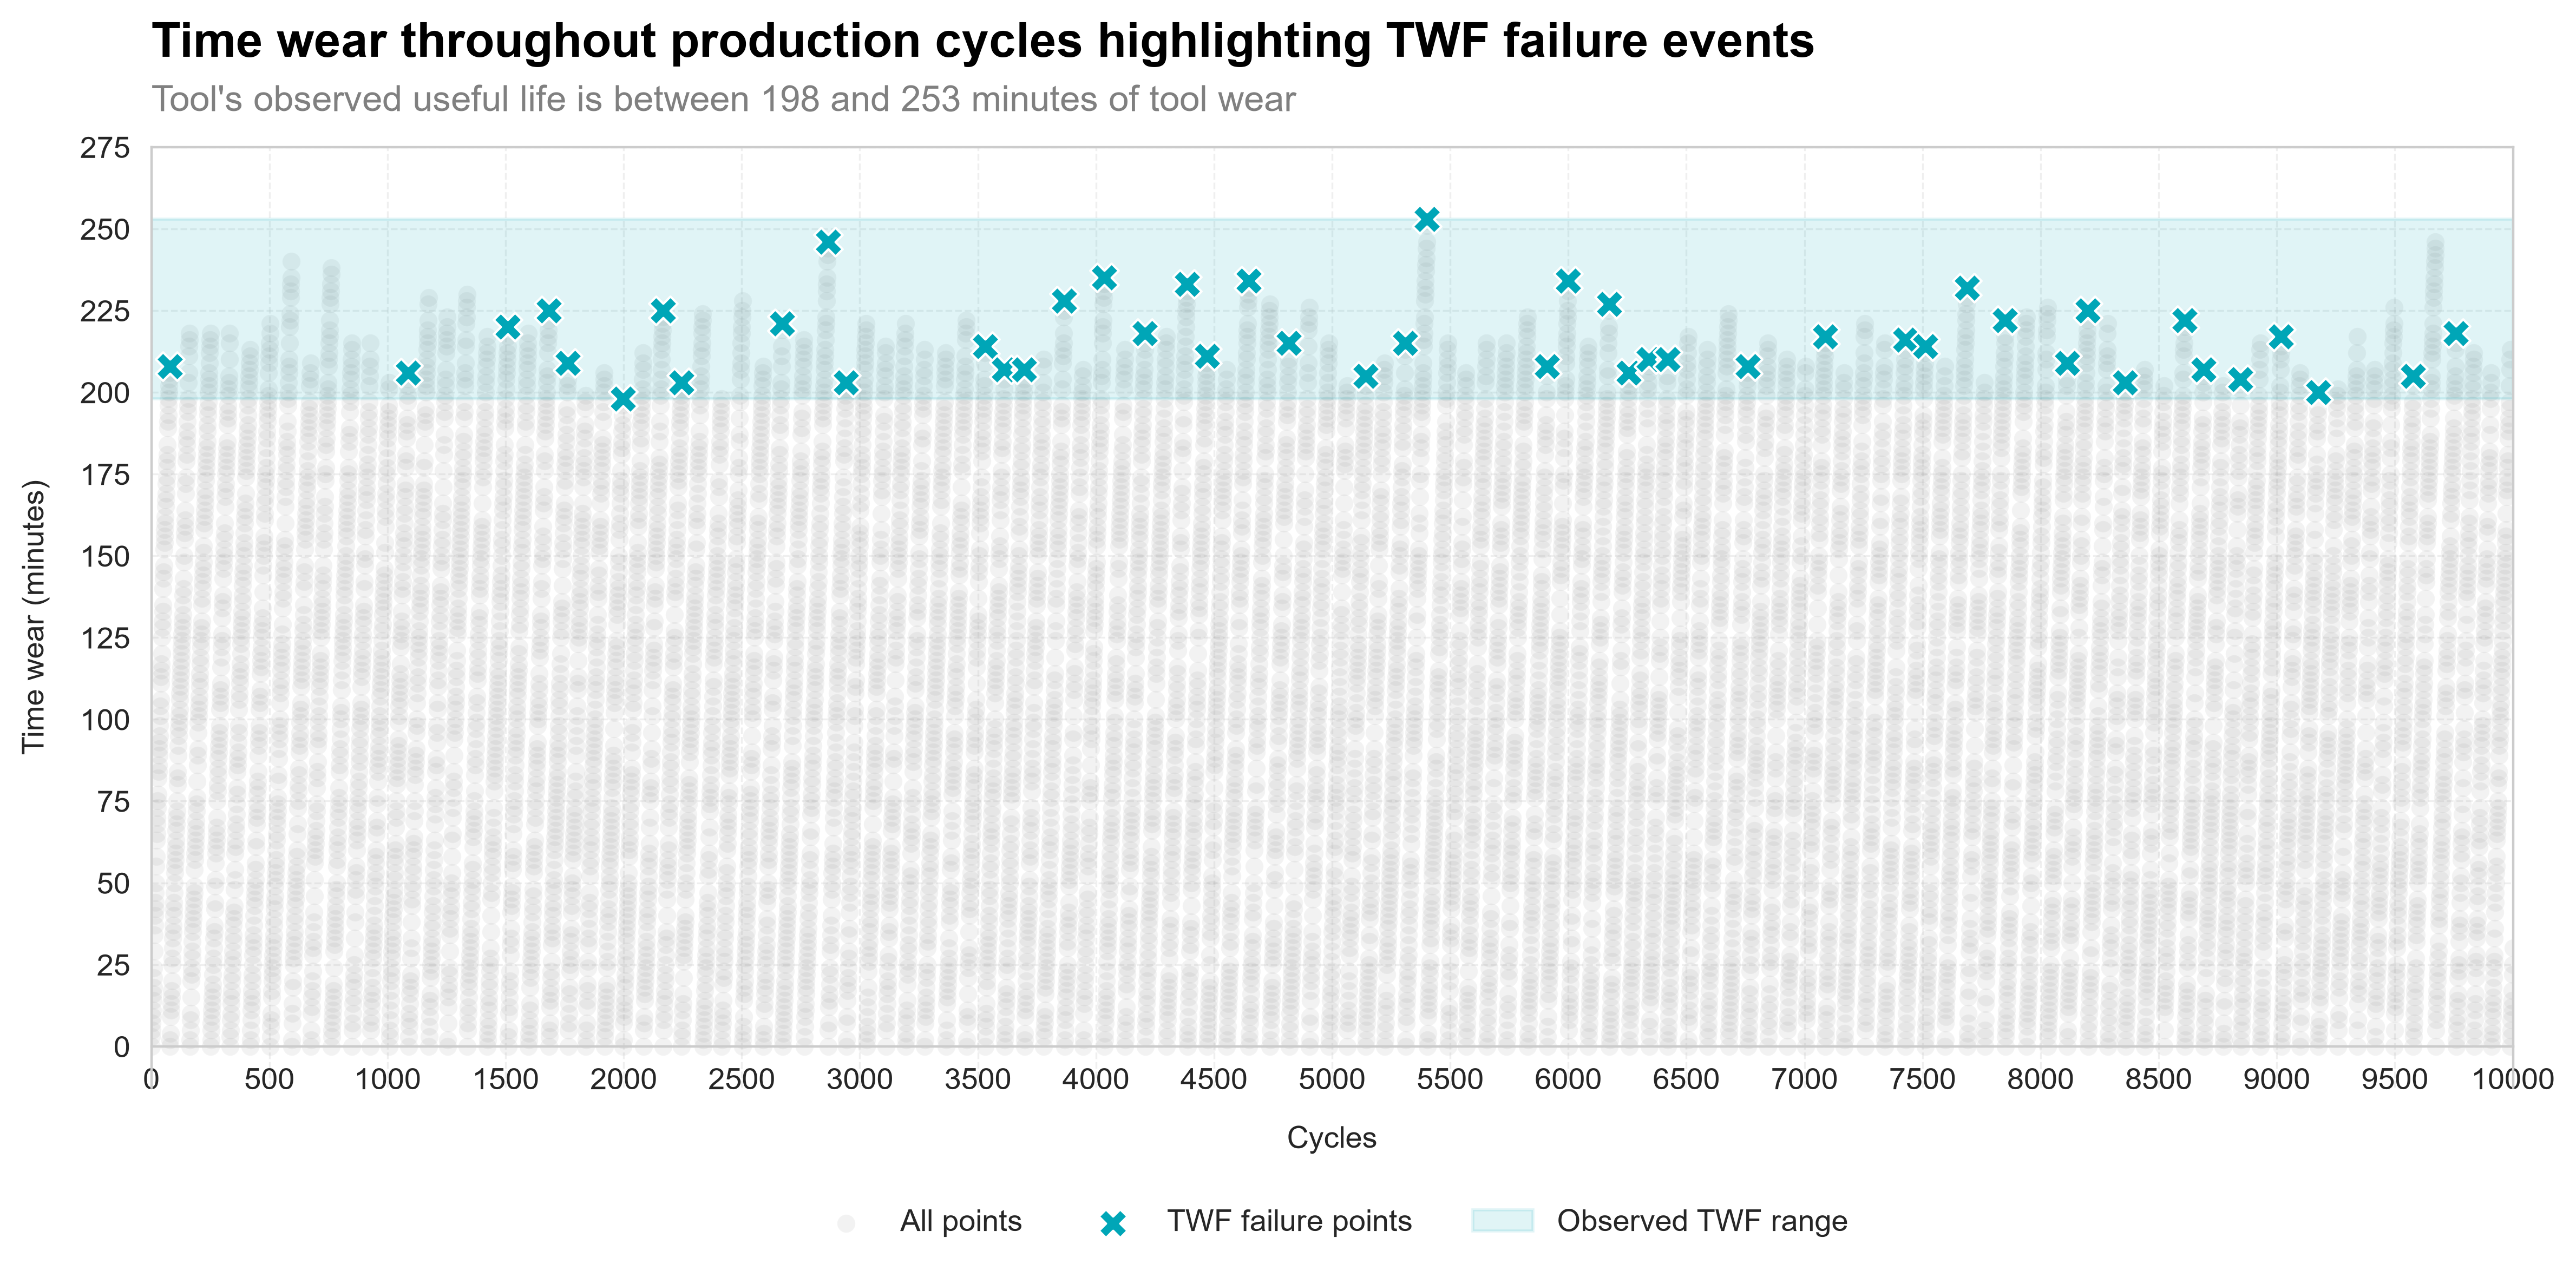

In [76]:
# Time-series plot of tool_wear_min

## Create a dataframe with only tool wear and failure columns
df_wear = df["tool_wear_min"]
rename_dict = {"tool_wear_min": "Tool wear (min)"}

## Create failure mode dataframe with TWF points
df_twf = df[df["tool_wear_failure"]]
df_twf = df_twf["tool_wear_min"]

## Create failure mode dataframe with OSF points
df_osf = df[df["overstrain_failure"]]
df_osf = df_osf["tool_wear_min"]


## Plot time-series

fig, ax = plt.subplots(figsize=(12, 6), dpi=400)
sns.set_style("whitegrid")

sns.scatterplot(x="register_id",
                y="tool_wear_min",
                data=df,
                alpha=0.1,
                color="#858585",
                label="All points",
                ax=ax)

## Plot failures
sns.scatterplot(data=df_twf,
                marker="X",
                s=90,
                color="#00A6B7",
                zorder=5,
                label="TWF failure points",
                ax=ax)

# Thresholds
upper_wear_thresh = 253
lower_wear_thresh = 198

# Observed TWF range
ax.axhspan(
    lower_wear_thresh, upper_wear_thresh,
    alpha=0.12,
    label="Observed TWF range",
    color = "#00A6B7"
)

## Title and Subtitle
# Title
ax.set_title(
    "Time wear throughout production cycles highlighting TWF failure events",
    fontsize=16,
    fontweight="bold",
    color="black",
    loc="left",
    pad=30
)

# Subtitle
ax.text(
    0, 1.03,
    "Tool's observed useful life is between 198 and 253 minutes of tool wear",
    transform=ax.transAxes,
    fontsize=12,
    color="gray",
    ha="left",
    va="bottom"
)

## Plot settings
ax.set_xlim(left=0, right=10000)
ax.set_xticks(np.arange(0,10001,500))
ax.set_yticks(np.arange(0,276,25))
ax.set_xlabel("Cycles", labelpad=10)
ax.set_ylabel("Time wear (minutes)", labelpad=10)

# Grid
ax.grid(
    axis="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.3
)

ax.spines['bottom'].set_position('zero')
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=3, 
    frameon=False
)
plt.tight_layout()
plt.savefig("../doc/twf_failure_events.png")
plt.show()

## Timeline of machined products by quality

Beyond the visual proof of random mix of machined products obtained from visualizing the tool wear scatter plot, the random distribution of different qualities of products could be attested by evaluating the transition matrix.

The transition matrix contains the probability of the next product being of the quality X given that the current product is of quality Y, for example. If the products are machined in batches, then the transition matrix would give a high probability of the next product being of the same quality of the current. In the other hand, if a random mix of products is machined then the probability of the next product being X would equals the percentagem of X in the sample, obtained during the statistical profiling. For refreshing these values, the distribution of products by quality is listed below:

- Low Quality: 60%
- Medium Quality: 30%
- High Quality: 10%

In [13]:
## Calculate the transition matrix

# Create a next type collumn
df['next_type'] = df['product_type'].shift(-1)

# Calculate the transition matrix normalizing the crosstab operation by the index and multiplying by 100, giving us percentages
transition_matrix = pd.crosstab(df['product_type'], df['next_type'], normalize='index') * 100

print(transition_matrix.round(1))

next_type        H     L     M
product_type                  
H             10.9  58.9  30.2
L              9.9  60.3  29.8
M              9.9  59.7  30.3


As shown by the transition matrix, the columns have similar values close to the percentage of appearance in the dataset, which enforces the random mix of products visualized in the time wear scatter plot, proving that products of different qualities are machined in a random order.

## Multivariate relationships

### Temperature difference and mechanical power

(xi, yi): (7.60, 5.91) (°C, kW)
(xf, yf): (8.60, 9.55) (°C, kW)


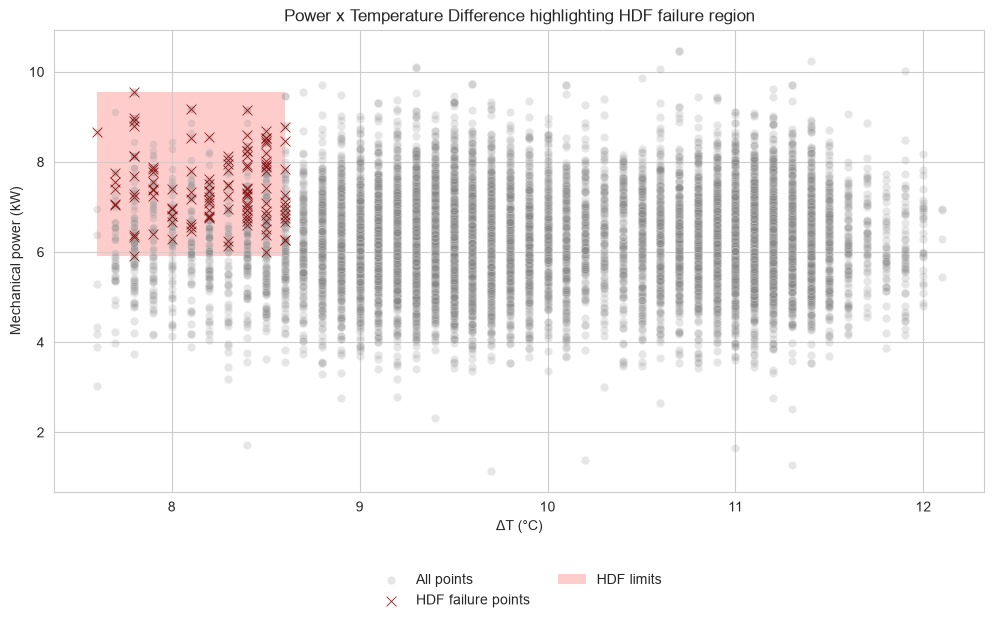

In [14]:
# Mechanical Power x Temperature Difference (scatter plot)

## Create a dataframe with only power and failure columns
df_for_plot = df_failure_mode[["mech_power_kwatts","delta_temperature_celsius"]]
rename_dict = {"delta_temperature_celsius": r"$\Delta$T (°C)",
               "mech_power_kwatts": "Mechanical power (kW)"}

## Create failure mode dataframe with HDF points
df_hdf = df_failure_mode[df_failure_mode["status"]=="HDF"]
df_hdf = df_hdf[["mech_power_kwatts", "delta_temperature_celsius"]]

## Plot time-series
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
# sns.lineplot(data=df_power.rename(rename_dict))
sns.scatterplot(data=df_for_plot.rename(rename_dict),
                x="delta_temperature_celsius",
                y="mech_power_kwatts",
                alpha=0.2,
                color="#858585",
                label="All points")

# Plot failures
sns.scatterplot(data=df_hdf,
                x="delta_temperature_celsius",
                y="mech_power_kwatts",
                marker="x",
                s=50,
                color="#920C0C",
                zorder=5,
                label="HDF failure points");

ax = plt.gca()

## Plot limit region using the trigger values encontered in the time-series
xi = float(df_hdf["delta_temperature_celsius"].min())
yi = float(df_hdf["mech_power_kwatts"].min())
dx = float(df_hdf["delta_temperature_celsius"].max() - df_hdf["delta_temperature_celsius"].min())
dy = float(df_hdf["mech_power_kwatts"].max() - df_hdf["mech_power_kwatts"].min())
print(f"(xi, yi): ({xi:.2f}, {yi:.2f}) (°C, kW)")
print(f"(xf, yf): ({xi+dx:.2f}, {yi+dy:.2f}) (°C, kW)")

rect = patches.Rectangle( (xi, yi), dx, dy, 
                         linewidth=0, 
                         facecolor='red', 
                         alpha=0.2, 
                         label="HDF limits",
                         zorder=-5)
ax.add_patch(rect)

## Plot settings
plt.title("Power x Temperature Difference highlighting HDF failure region")
plt.xlabel(r"$\Delta$T (°C)")
plt.ylabel("Mechanical power (kW)")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2, 
    frameon=False
)
plt.show()

In [15]:
# Testing how many false positives an alarm set to the HDF limits shown would give
allerts = df_failure_mode[(df_failure_mode["delta_temperature_celsius"] <= (xi+dx))
                          & (df_failure_mode["mech_power_kwatts"] >= yi)].shape[0]
failures = df_failure_mode[df_failure_mode["status"]=="HDF"].shape[0]
print(f"Using the HDF limits, the alarm would ring {allerts} times giving {(allerts-failures)/allerts*100:.1f} % of false positives")

Using the HDF limits, the alarm would ring 512 times giving 77.5 % of false positives


- As can be seen by the scatter plot, combining the limits on temperature difference and mechanical power would still be not sufficient for predicting the HDF failures, as the region where the failure points are confined have many of non-failure data points.

### Temperature Difference and Rotational Speed

(xi, yi): (7.60, 1212.00) (°C, kW)
(xf, yf): (8.60, 1379.00) (°C, kW)


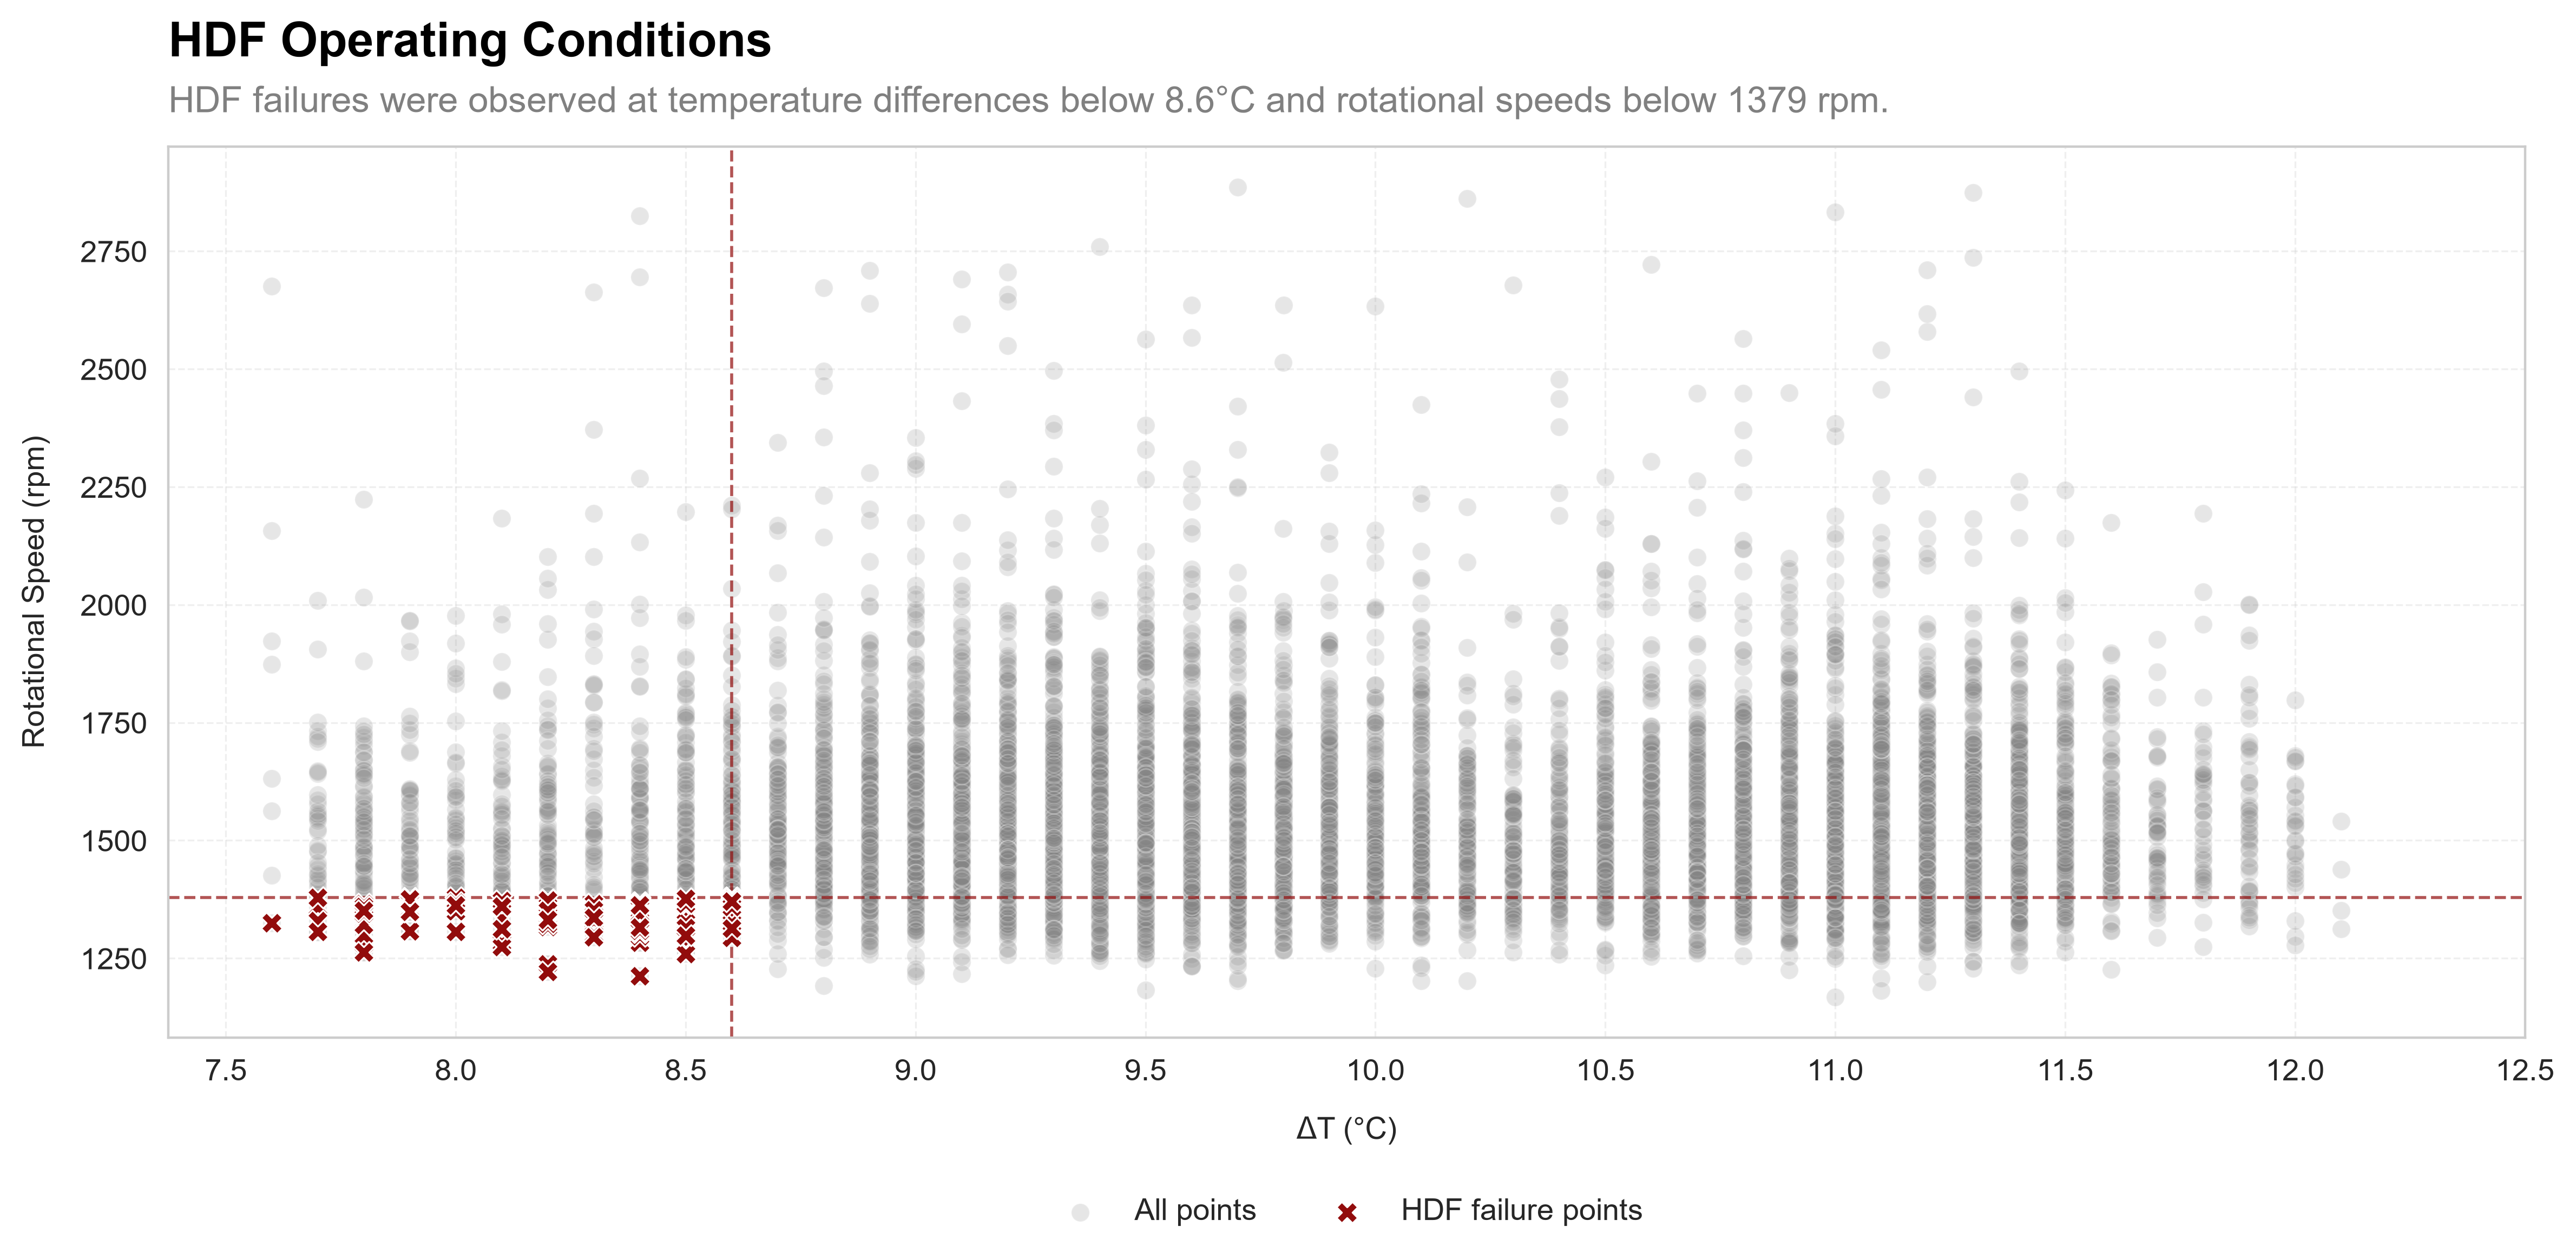

In [86]:
# Rotational Speed x Temperature Difference (scatter plot)

## Create a dataframe with only power and failure columns
df_for_plot = df_failure_mode[["rotational_speed_rpm","delta_temperature_celsius"]]
rename_dict = {"delta_temperature_celsius": r"$\Delta$T (°C)",
               "rotational_speed_rpm": "Rotational Speed (rpm)"}

## Create failure mode dataframe with HDF points
df_hdf = df_failure_mode[df_failure_mode["status"]=="HDF"]
df_hdf = df_hdf[["rotational_speed_rpm", "delta_temperature_celsius"]]

## Plot time-series
plt.figure(figsize=(12, 6), dpi=400)
sns.set_style("whitegrid")
# sns.lineplot(data=df_power.rename(rename_dict))
sns.scatterplot(data=df_for_plot.rename(rename_dict),
                x="delta_temperature_celsius",
                y="rotational_speed_rpm",
                alpha=0.2,
                color="#858585",
                label="All points")

# Plot failures
sns.scatterplot(data=df_hdf,
                x="delta_temperature_celsius",
                y="rotational_speed_rpm",
                marker="X",
                s=50,
                color="#920C0C",
                zorder=5,
                label="HDF failure points");

ax = plt.gca()

## Plot limit region using the trigger values encontered in the time-series
xi = float(df_hdf["delta_temperature_celsius"].min())
yi = float(df_hdf["rotational_speed_rpm"].min())
dx = float(df_hdf["delta_temperature_celsius"].max() - df_hdf["delta_temperature_celsius"].min())
dy = float(df_hdf["rotational_speed_rpm"].max() - df_hdf["rotational_speed_rpm"].min())
print(f"(xi, yi): ({xi:.2f}, {yi:.2f}) (°C, kW)")
print(f"(xf, yf): ({xi+dx:.2f}, {yi+dy:.2f}) (°C, kW)")

# rect = patches.Rectangle( (xi, yi), dx, dy, 
#                          linewidth=0, 
#                          facecolor='red', 
#                          alpha=0.2, 
#                          label="Observed HDF operating region",
#                          zorder=-5)
# ax.add_patch(rect)


# Thresholds
delta_t_threshold = 8.6
rpm_threshold = 1379

# Threshold lines
ax.axvline(
    delta_t_threshold,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    color="#920C0C"
)

ax.axhline(
    rpm_threshold,
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    color="#920C0C"
)

## Plot settings

# Title
ax.set_title(
    "HDF Operating Conditions",
    fontsize=16,
    fontweight="bold",
    color="black",
    loc="left",
    pad=30
)

# Subtitle
ax.text(
    0, 1.03,
    "HDF failures were observed at temperature differences below 8.6°C and rotational speeds below 1379 rpm.",
    transform=ax.transAxes,
    fontsize=12,
    color="gray",
    ha="left",
    va="bottom"
)

plt.xlabel(r"$\Delta$T (°C)", labelpad=10)
plt.xticks(np.arange(7.5, 12.6, 0.5))
plt.ylabel("Rotational Speed (rpm)", labelpad=10)
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=3, 
    frameon=False
)

# Grid
ax.grid(
    axis="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.3
)

plt.tight_layout()
plt.savefig("../doc/hdf_operating_conditions.png")
plt.show()

In [17]:
# Testing how many false positives an alarm set to the HDF limits shown would give
allerts = df_failure_mode[(df_failure_mode["delta_temperature_celsius"] < (xi+dx))
                          & (df_failure_mode["rotational_speed_rpm"] < (yi+dy))].shape[0]
failures = df_failure_mode[df_failure_mode["status"]=="HDF"].shape[0]

print(f"Using the HDF limits, the alarm would ring {allerts} times giving {(allerts-failures)/allerts*100:.1f} % of false positives")

Using the HDF limits, the alarm would ring 115 times giving 0.0 % of false positives


- The Rotational Speed x Temperature Difference scatter plot gives a well confined rectangular region that contains all the failure points and none normal operation data points. In conclusion, setting an alarm to ring when the difference of temperature is below 8.6°C and the rotational speed is below 1379 rpm would predict all the HDF failures in the operational window analyzed without false positives. Further studies for determining an useful alarm should include a safety margin allowing some false positives.

### Torque x Time Wear

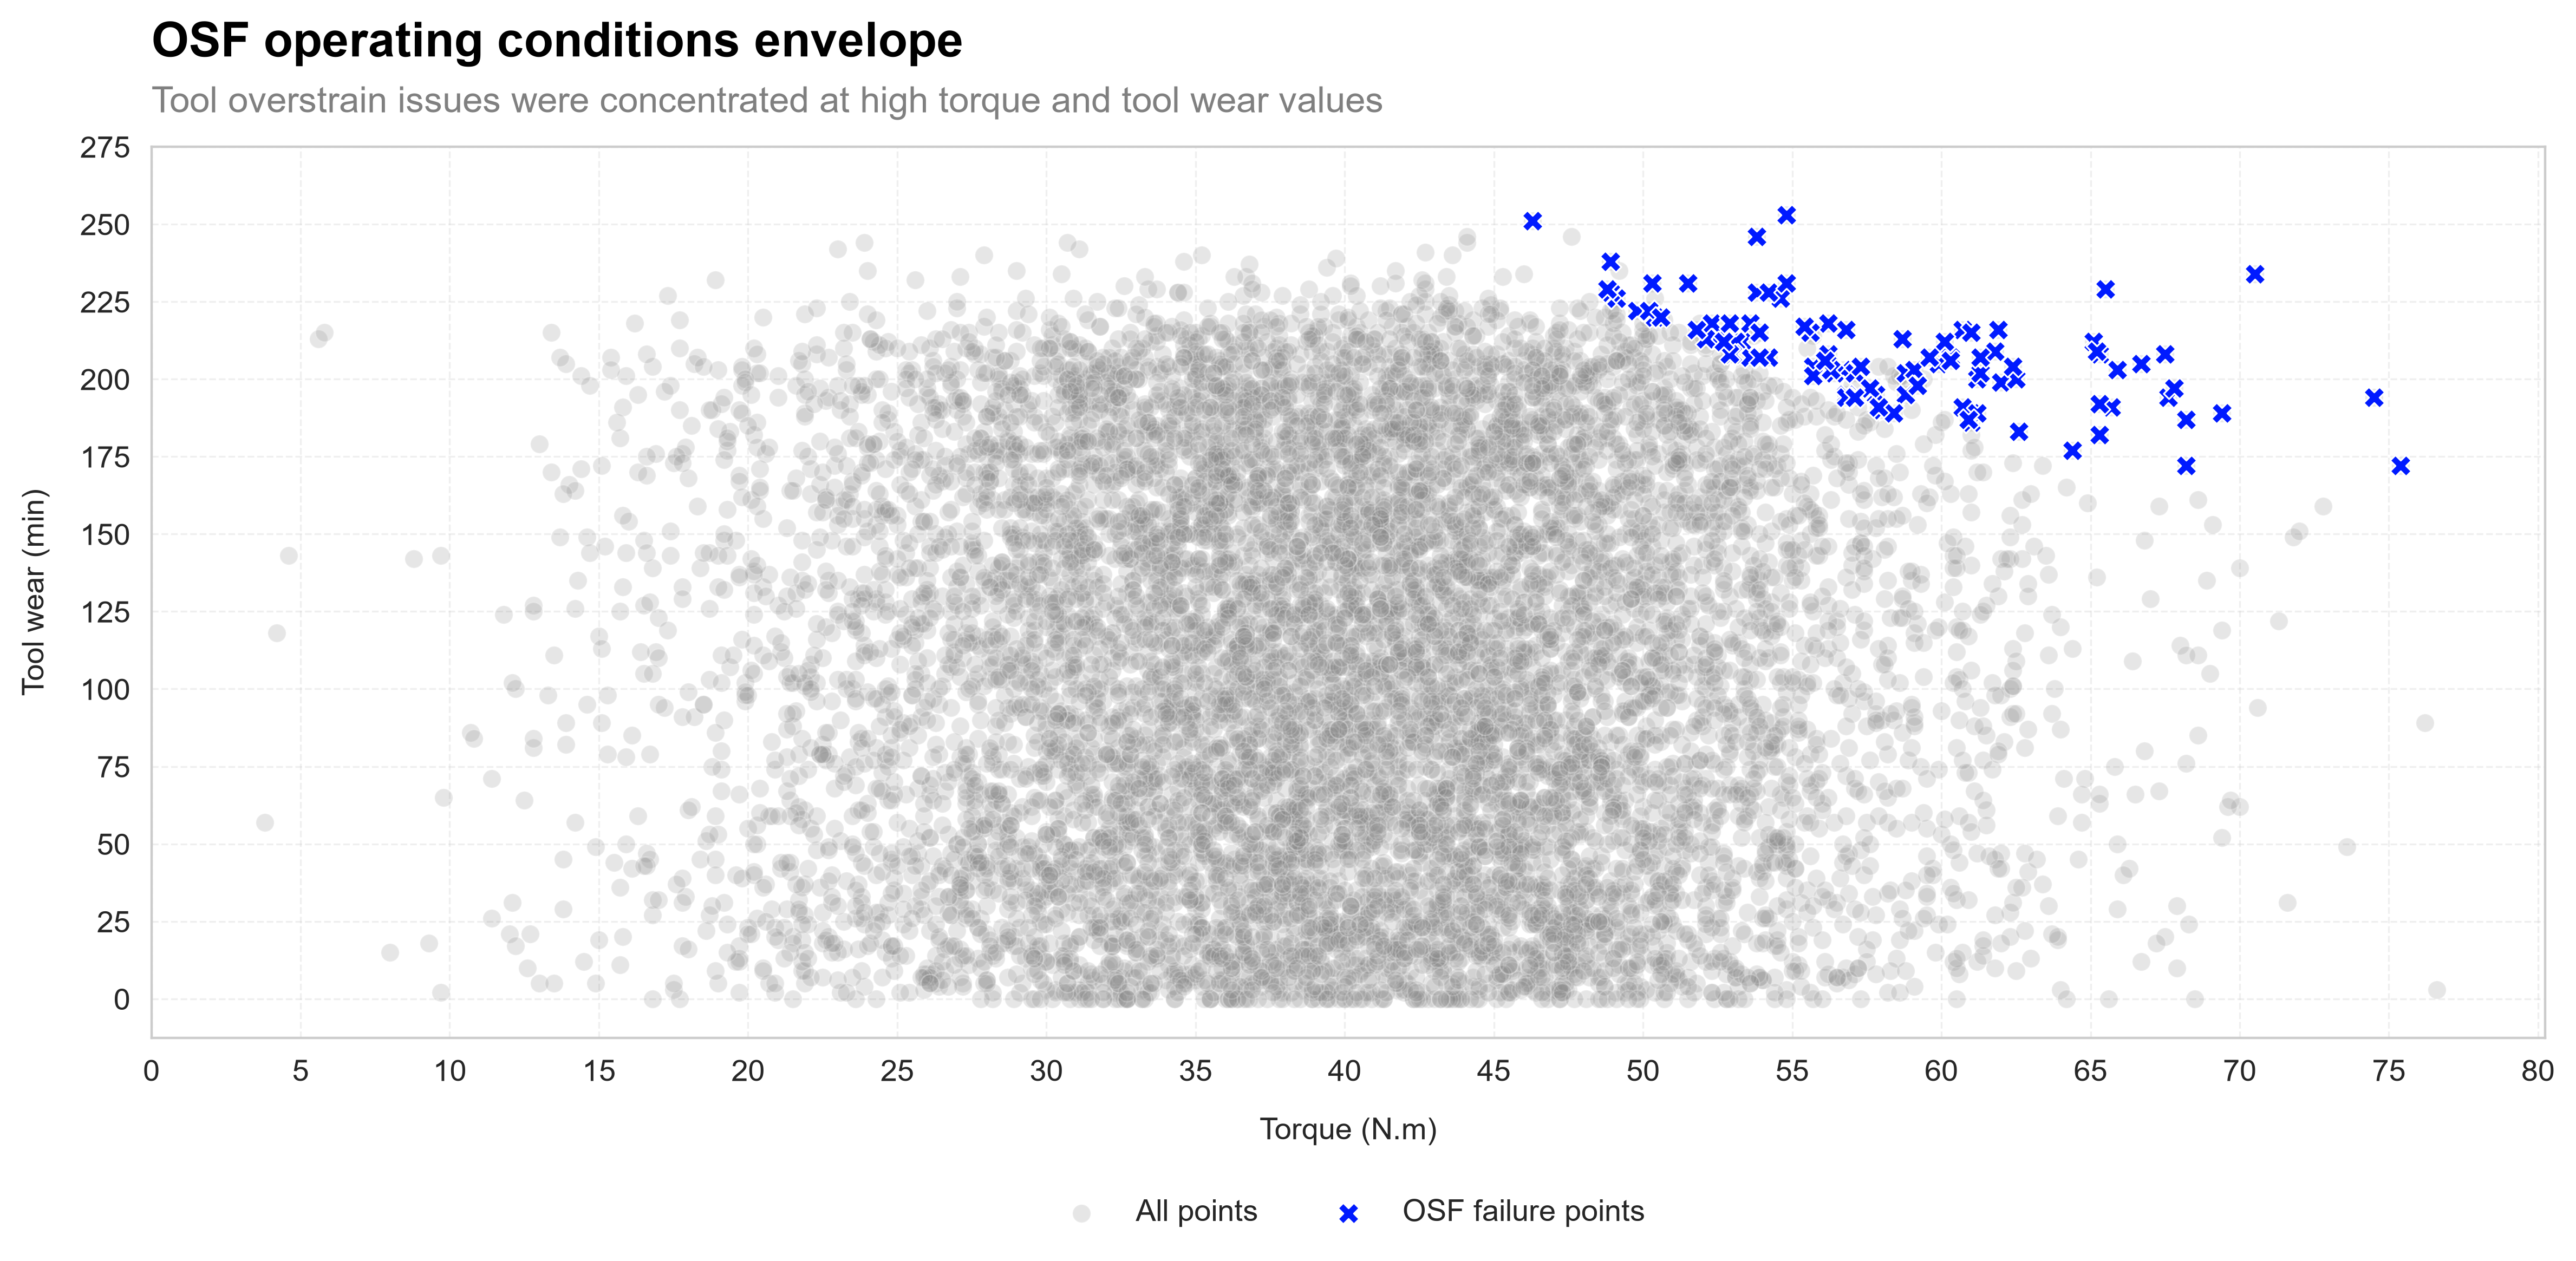

In [98]:
# Torque x Time Wear (scatter plot)

## Create a dataframe with only power and failure columns
df_for_plot = df[["torque_nm","tool_wear_min"]]
rename_dict = {"tool_wear_min": "Tool wear (min)",
               "torque_nm": "Torque (N.m)"}

## Create failure mode dataframe with HDF points
df_osf = df[df["overstrain_failure"]]
df_osf = df_osf[["torque_nm", "tool_wear_min"]]

## Plot time-series
plt.figure(figsize=(12, 6), dpi=400)
sns.set_style("whitegrid")
sns.scatterplot(data=df_for_plot.rename(rename_dict),
                x="torque_nm",
                y="tool_wear_min",
                alpha=0.2,
                color="#858585",
                label="All points")

# Plot failures
sns.scatterplot(data=df_osf,
                x="torque_nm",
                y="tool_wear_min",
                marker="X",
                s=50,
                color="#001AFF",
                zorder=5,
                label="OSF failure points")

ax = plt.gca()

# Title
ax.set_title(
    "OSF operating conditions envelope",
    fontsize=16,
    fontweight="bold",
    color="black",
    loc="left",
    pad=30
)

# Subtitle
ax.text(
    0, 1.03,
    "Tool overstrain issues were concentrated at high torque and tool wear values",
    transform=ax.transAxes,
    fontsize=12,
    color="gray",
    ha="left",
    va="bottom"
)

## Plot settings
ax.set_xticks(np.arange(0,81,5))
ax.set_yticks(np.arange(0,276,25))
plt.xlabel("Torque (N.m)", labelpad=10)
plt.ylabel("Tool wear (min)", labelpad=10)
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2, 
    frameon=False
)

# Grid
ax.grid(
    axis="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.3
)

plt.tight_layout()
plt.savefig("../doc/osf_failure_events.png")
plt.show()

- As can be seen by the scatter plot, there is a potential envelope of data points in the Tool Wear x Torque graph that could be used to predict OSF failure points. Since this envelope isn't a rectangular region, further investigation on using clustering methods to group these points and defining a failure region is required.

## Conclusion

- Temperature time-series graph shows that the sensors captured fluctuating signals during all the operational window analyzed which motivated the investigation of two hypothesis: products of different qualities being machined in batches leading to different operational regimes or sensor issues causing a drifiting behaviour. The study of the order of machined products, by means of analysing the graph "Time wear time-series plot" and evaluating the transition matrix for product quality feature, proved that both hypothesis weren't valid.

- Furthermore, the discovery of a crisp, well-defined temperature difference threshold for HDF failures at strictly $8.6^\circ\text{C}$ strongly discards the hypothesis of sensor drift, leaving the necessity of coming up with other features that could be associated with different temperature regimes.

- Tool Wear Failures (TWF) are predominantly observed between 198 and 253 minutes of operation. This cluster indicates that the useful life of the tool is effectively bounded within this range, serving as a critical indicator for planned replacement strategies.

- Not all tool exchange events coincide with Tool Wear Failure (TWF), indicating the application of a preventive maintenance policy.

- Time-series analysis of the Mechanical Power reveals that all PWF failure points occur above 9 kW and below 3.5 kW.

- The Rotational Speed x Temperature Difference scatter plot gives a  region that contains all the HDF failure where the difference of temperature is below 8.6°C and the rotational speed is below 1379 rpm.

- There is a potential envelope of data points in the Tool Wear x Torque graph that could be used to predict OSF failure points, leaving space for future studies using clustering methods for defining a failure locus.